Simulating 5000 actions per problem for 200 policy parameters...


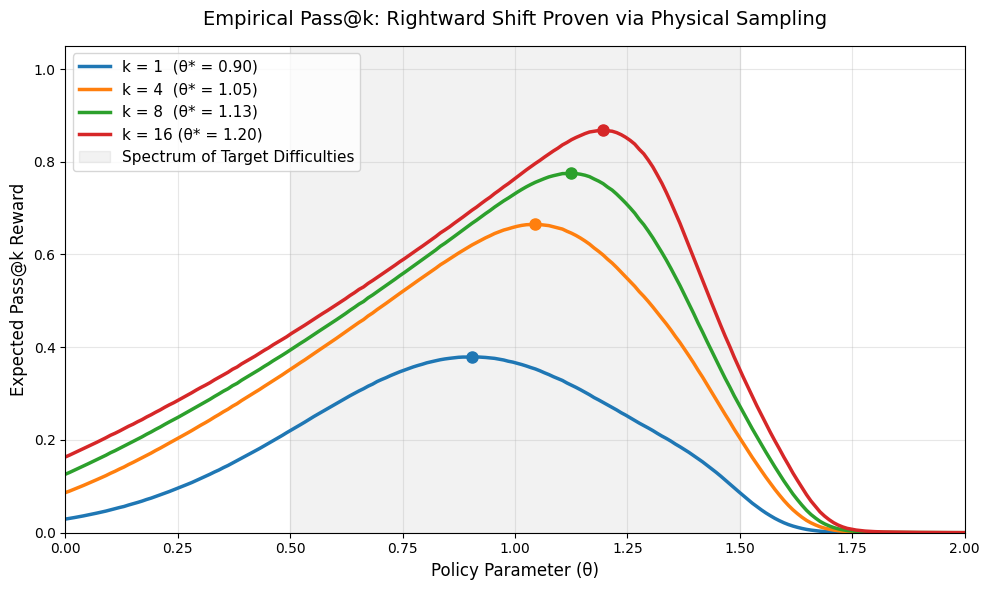

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. EMPIRICAL SAMPLING FOR THE CONTINUOUS SPECTRUM
# =====================================================================

def compute_empirical_curves(thetas, k_values, N=5000):
    """
    Computes expected Pass@k by physically sampling N actions for every
    combination of Theta and Problem Difficulty (X).
    """
    sigma = 0.1
    
    # 200 discrete problems to approximate the continuous spectrum
    X = np.linspace(0.5, 1.5, 200) 
    W = 0.07 - 0.04 * X
    
    # Dictionary to hold the final expected rewards for each k
    expected_rewards = {k: np.zeros(len(thetas)) for k in k_values}
    
    print(f"Simulating {N} actions per problem for {len(thetas)} policy parameters...")
    
    for i, theta in enumerate(thetas):
        # 1. The target mean for the policy: theta * X
        # Shape of loc is (200,), representing the mean action for each problem X
        loc = theta * X
        
        # 2. GENERATE THE ACTIONS (The Monte Carlo Step)
        # We draw N random samples for every single problem simultaneously.
        # Z shape becomes (200 problems, N sampled actions)
        Z = np.random.normal(loc=loc[:, np.newaxis], scale=sigma, size=(len(X), N))
        
        # 3. SCORE THE ACTIONS
        # Format X and W to broadcast correctly against the Z matrix
        X_col = X[:, np.newaxis]
        W_col = W[:, np.newaxis]
        
        # Calculate the actual reward [0, 1] for every single sampled action
        # This replaces the analytical H and D equations entirely!
        raw_rewards = np.exp(-((Z - X_col**2)**2) / W_col)
        
        # 4. EMPIRICAL SUCCESS PROBABILITY
        # The average of the N physical actions becomes our single-shot P_success
        P_success = np.mean(raw_rewards, axis=1)
        
        # 5. APPLY PASS@K AND AVERAGE ACROSS BATCH
        for k in k_values:
            pass_k_score = 1 - (1 - P_success)**k
            expected_rewards[k][i] = np.mean(pass_k_score)
            
    return expected_rewards

# =====================================================================
# 2. COMPUTE THE CURVES
# =====================================================================
thetas = np.linspace(0.0, 2.0, 200)
k_values = [1, 4, 8, 16] 

# Run the massive Monte Carlo simulation
results = compute_empirical_curves(thetas, k_values, N=5000)

# =====================================================================
# 3. PLOT THE RESULTS
# =====================================================================
plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, k in enumerate(k_values):
    rewards = results[k]
    
    # Find the peak
    best_idx = np.argmax(rewards)
    best_theta = thetas[best_idx]
    max_reward = rewards[best_idx]
    
    plt.plot(thetas, rewards, label=f'k = {k:<2} (θ* = {best_theta:.2f})', 
             color=colors[idx], linewidth=2.5)
    
    # Mark the peak
    plt.plot(best_theta, max_reward, marker='o', markersize=8, color=colors[idx])

plt.title("Empirical Pass@k: Rightward Shift Proven via Physical Sampling", 
          fontsize=14, pad=15)
plt.xlabel("Policy Parameter (θ)", fontsize=12)
plt.ylabel("Expected Pass@k Reward", fontsize=12)

plt.axvspan(0.5, 1.5, color='gray', alpha=0.1, label='Spectrum of Target Difficulties')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.xlim(0.0, 2.0)
plt.tight_layout()

plt.show()

In [7]:
import numpy as np
from scipy.stats import binom, betabinom
from scipy.optimize import minimize

# 1. SETUP - LARGER BATCH
theta = 0.5
sigma = 0.1
n_problems = 64 # Larger batch for EB to work
n_generations = 8

X = np.linspace(0.5, 1.5, n_problems)
W = 0.07 - 0.04 * X

# Calculate True p_i
np.random.seed(42)
Z_large = np.random.normal(loc=theta * X[:, None], scale=sigma, size=(n_problems, 10000))
P_succ_large = np.exp(-((Z_large - X[:, None]**2)**2) / W[:, None])
true_p = np.mean(P_succ_large, axis=1)

def run_trial():
    Z = np.random.normal(loc=theta * X[:, None], scale=sigma, size=(n_problems, n_generations))
    P_succ = np.exp(-((Z - X[:, None]**2)**2) / W[:, None])
    Y = np.random.binomial(1, P_succ)
    
    p_ub = np.max(Y, axis=1)
    
    from pass_at_k import BetaBinomialPassAtK, NPMLEBinomialPassAtK
    eb_bb = BetaBinomialPassAtK()
    eb_npmle = NPMLEBinomialPassAtK(verbose=False, reg_alpha=1e-3, include_empirical_support=False)
    
    eb_bb.fit(Y.sum(axis=1), [n_generations]*n_problems)
    eb_npmle.fit(Y.sum(axis=1), [n_generations]*n_problems)
    eb_bb.predict([n_generations], method="posterior")
    eb_npmle.predict([n_generations], method="posterior")
    p_bb = eb_bb._psi[:, 0]
    p_npmle = eb_npmle._psi[:, 0]
    return p_ub, p_bb, p_npmle

# 2. RUN SIMULATION
num_trials = 200
errors_ub, errors_bb, errors_npmle = [], [], []

for _ in range(num_trials):
    p_ub, p_bb, p_npmle = run_trial()
    errors_ub.append(p_ub - true_p)
    errors_bb.append(p_bb - true_p)
    errors_npmle.append(p_npmle - true_p)

# 3. COMPUTE METRICS
def compute_metrics(errors):
    bias = np.mean(errors, axis=0)
    variance = np.var(errors, axis=0)
    mse = np.mean(errors**2, axis=0)
    return np.mean(np.abs(bias)), np.mean(variance), np.mean(mse)

b_ub, v_ub, mse_ub = compute_metrics(np.array(errors_ub))
b_bb, v_bb, mse_bb = compute_metrics(np.array(errors_bb))
b_npmle, v_npmle, mse_npmle = compute_metrics(np.array(errors_npmle))

print(f"\n--- Unbiased Estimator ---")
print(f"Mean Abs Bias: {b_ub:.6f}")
print(f"Mean Variance: {v_ub:.6f}")
print(f"Mean MSE:      {mse_ub:.6f}")

print(f"\n--- Beta-Binomial EB ---")
print(f"Mean Abs Bias: {b_bb:.6f}")
print(f"Mean Variance: {v_bb:.6f}")
print(f"Mean MSE:      {mse_bb:.6f}")

print(f"\n--- NPMLE EB ---")
print(f"Mean Abs Bias: {b_npmle:.6f}")
print(f"Mean Variance: {v_npmle:.6f}")
print(f"Mean MSE:      {mse_npmle:.6f}")


--- Unbiased Estimator ---
Mean Abs Bias: 0.173144
Mean Variance: 0.033011
Mean MSE:      0.110131

--- Beta-Binomial EB ---
Mean Abs Bias: 0.194792
Mean Variance: 0.013465
Mean MSE:      0.067605

--- NPMLE EB ---
Mean Abs Bias: 0.175480
Mean Variance: 0.017396
Mean MSE:      0.067251


In [ ]:
import numpy as np

# 1. SETUP - LARGER BATCH
theta = 1.0
sigma = 0.1
n_problems = 1 # Larger batch for EB to work
n_generations = 4


# Calculate True p_i
np.random.seed(42)
N_large = 10000
# X_large = np.linspace(0.5, 1.5, N_large)
X_large = np.random.uniform(0.5, 1.5, N_large)
W_large = 0.07 - 0.04 * X_large
# Step 1: Calculate the EXACT analytical marginal success probability p(x)
# D is the combined variance denominator: W + 2*sigma^2
D_large = W_large + 2 * sigma**2
# H is the maximum probability ceiling: sqrt(W / D)
H_large = np.sqrt(W_large / D_large)
# The exact true probability without sampling a single Z!
true_p = H_large * np.exp(-((theta * X_large - X_large**2)**2) / D_large)
# Step 2: Calculate the true theoretical Pass@(k-1)
true_pass_k_minus_1 = 1 - (1 - true_p)**(n_generations - 1)
# Step 3: Compute the True Expected Gradient for the Batch
# We still sample Z here because the gradient involves Z in the score function
Z_large = np.random.normal(loc=theta * X_large[:, None], scale=sigma, size=(N_large, n_generations))
P_succ_large = np.exp(-((Z_large - X_large[:, None]**2)**2) / W_large[:, None])
score_large = ((Z_large - theta * X_large[:, None]) * X_large[:, None]) / sigma**2

# The true conditional expected reward
expected_reward = P_succ_large + (1 - P_succ_large) * true_pass_k_minus_1[:, None]

# The flawless Oracle policy gradient
true_g = np.mean(expected_reward * score_large)

def run_trial():
    # X = np.linspace(0.5, 1.5, n_problems)
    X = np.random.uniform(0.5, 1.5, n_problems)
    W = 0.07 - 0.04 * X
    Z = np.random.normal(loc=theta * X[:, None], scale=sigma, size=(n_problems, n_generations))
    P_succ = np.exp(-((Z - X[:, None]**2)**2) / W[:, None])
    score = ((Z - theta * X[:, None]) * X[:, None]) / sigma**2
    Y = np.random.binomial(1, P_succ)
    
    p_ub = np.max(Y, axis=1, keepdims=True) # when k = n_generations, the conditional is the same as the unconditional pass@k
    # subtract max@(k-1). below code checks if any other action was successful
    sum_others = np.sum(Y, axis=1, keepdims=True) - Y
    loo_baseline = (sum_others > 0).astype(float)
    adv_ub = p_ub - loo_baseline
    g_ub = np.mean(adv_ub * score)
    
    from pass_at_k import BetaBinomialPassAtK, NPMLEBinomialPassAtK
    eb_bb = BetaBinomialPassAtK()
    eb_npmle = NPMLEBinomialPassAtK(verbose=False, reg_alpha=1e-3, include_empirical_support=False)
    
    eb_bb.fit(Y.sum(axis=1), [n_generations]*n_problems)
    eb_npmle.fit(Y.sum(axis=1), [n_generations]*n_problems)
    eb_bb.predict([n_generations-1], method="posterior")
    eb_npmle.predict([n_generations-1], method="posterior")
    p_bb = np.maximum(np.tile(eb_bb._psi[:, [0]], (1, n_generations)), Y)
    p_npmle = np.maximum(np.tile(eb_npmle._psi[:, [0]], (1, n_generations)), Y)

    # baseline
    eb_bb.predict([n_generations], method="posterior") # unconditonal pass@k given problem X
    baseline_bb = eb_bb._psi[:, [0]]
    eb_npmle.predict([n_generations], method="posterior")
    baseline_npmle = eb_npmle._psi[:, [0]]
    adv_bb = p_bb - baseline_bb
    adv_npmle = p_npmle - baseline_npmle
    # adv_bb = p_bb
    # adv_npmle = p_npmle

    g_bb = np.mean(adv_bb * score)
    g_npmle = np.mean(adv_npmle * score)
    return g_ub, g_bb, g_npmle

# 2. RUN SIMULATION
num_trials = 200
errors_ub, errors_bb, errors_npmle = [], [], []

for _ in range(num_trials):
    g_ub, g_bb, g_npmle = run_trial()
    errors_ub.append(g_ub - true_g)
    errors_bb.append(g_bb - true_g)
    errors_npmle.append(g_npmle - true_g)

# 3. COMPUTE METRICS
def compute_metrics(errors):
    bias = np.mean(errors, axis=0)
    variance = np.var(errors, axis=0)
    mse = np.mean(errors**2, axis=0)
    return bias, variance, mse

b_ub, v_ub, mse_ub = compute_metrics(np.array(errors_ub))
b_bb, v_bb, mse_bb = compute_metrics(np.array(errors_bb))
b_npmle, v_npmle, mse_npmle = compute_metrics(np.array(errors_npmle))

print(f"\n--- Unbiased Estimator ---")
print(f"Mean Abs Bias: {b_ub:.6f}")
print(f"Mean Variance: {v_ub:.6f}")
print(f"Mean MSE:      {mse_ub:.6f}")

print(f"\n--- Beta-Binomial EB ---")
print(f"Mean Abs Bias: {b_bb:.6f}")
print(f"Mean Variance: {v_bb:.6f}")
print(f"Mean MSE:      {mse_bb:.6f}")

print(f"\n--- NPMLE EB ---")
print(f"Mean Abs Bias: {b_npmle:.6f}")
print(f"Mean Variance: {v_npmle:.6f}")
print(f"Mean MSE:      {mse_npmle:.6f}")


--- Unbiased Estimator ---
Mean Abs Bias: -0.038765
Mean Variance: 1.690709
Mean MSE:      1.692212

--- Beta-Binomial EB ---
Mean Abs Bias: -0.075984
Mean Variance: 0.358151
Mean MSE:      0.363925

--- NPMLE EB ---
Mean Abs Bias: -0.059831
Mean Variance: 0.451488
Mean MSE:      0.455068


Starting Stochastic Gradient Ascent...
Final Thetas:
  Unbiased LOO: 1.1161
  Beta-Binomial EB: 1.0615
  NPMLE EB: 1.0491


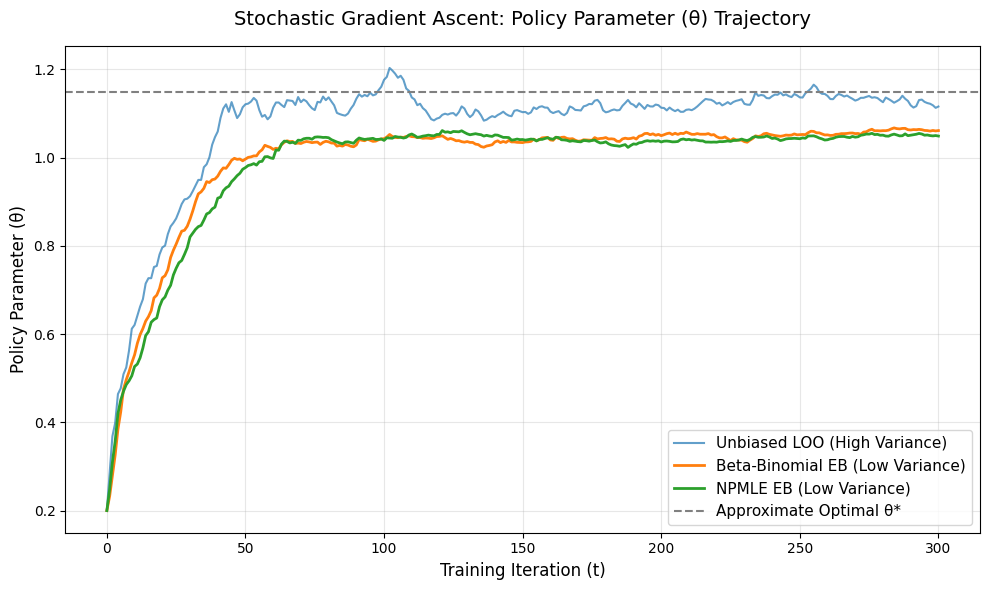

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from pass_at_k import BetaBinomialPassAtK, NPMLEBinomialPassAtK

# =====================================================================
# 1. SETUP THE ENVIRONMENT
# =====================================================================
sigma = 0.1
n_problems = 64
n_generations = 8
iterations = 300
initial_theta = 0.2
base_lr = 1 # Base Learning Rate

# Initialize the models
eb_bb = BetaBinomialPassAtK(verbose=False)
eb_npmle = NPMLEBinomialPassAtK(verbose=False, reg_alpha=1e-3, include_empirical_support=False)

# Track the parameter trajectories
thetas = {
    'Unbiased LOO': initial_theta, 
    'Beta-Binomial EB': initial_theta, 
    'NPMLE EB': initial_theta
}

trajectories = {
    'Unbiased LOO': [initial_theta], 
    'Beta-Binomial EB': [initial_theta], 
    'NPMLE EB': [initial_theta]
}

print("Starting Stochastic Gradient Ascent...")

# =====================================================================
# 2. THE TRAINING LOOP
# =====================================================================
for t in range(1, iterations + 1):
    # The Decaying Learning Rate (1/sqrt(t))
    lr = base_lr / np.sqrt(t)
    
    # Sample a fresh, random mini-batch of problems (Avoiding the linspace trap!)
    X = np.random.uniform(0.5, 1.5, n_problems)
    W = 0.07 - 0.04 * X
    
    # Train each estimator independently
    for method in thetas.keys():
        current_theta = thetas[method]
        
        # 1. ROLLOUT: Generate actions and environment rewards
        Z = np.random.normal(loc=current_theta * X[:, None], scale=sigma, size=(n_problems, n_generations))
        P_succ = np.exp(-((Z - X[:, None]**2)**2) / W[:, None])
        Y = np.random.binomial(1, P_succ)
        
        # 2. COMPUTE SCORE FUNCTION
        score = ((Z - current_theta * X[:, None]) * X[:, None]) / sigma**2
        
        # 3. COMPUTE ADVANTAGE & GRADIENT
        if method == 'Unbiased LOO':
            p_ub = np.max(Y, axis=1, keepdims=True)
            sum_others = np.sum(Y, axis=1, keepdims=True) - Y
            loo_baseline = (sum_others > 0).astype(float)
            adv = p_ub - loo_baseline
            
        elif method == 'Beta-Binomial EB':
            # No EMA in this cell: marginal under Beta(1,1) (independent of Y)
            eb_bb.alpha_, eb_bb.beta_ = 1.0, 1.0
            eb_bb.predict([n_generations - 1], method="integrated")
            psi_km1 = float(np.asarray(eb_bb._psi).ravel()[0])
            eb_bb.predict([n_generations], method="integrated")
            psi_k = float(np.asarray(eb_bb._psi).ravel()[0])
            p_bb = np.maximum(psi_km1, Y)
            adv = p_bb - psi_k
            eb_bb.fit(Y.sum(axis=1), [n_generations] * n_problems)
            
        elif method == 'NPMLE EB':
            eb_npmle.fit(Y.sum(axis=1), [n_generations]*n_problems)
            eb_npmle.predict([n_generations-1], method="posterior")
            p_npmle = np.maximum(np.tile(eb_npmle._psi[:, [0]], (1, n_generations)), Y)
            
            eb_npmle.predict([n_generations], method="posterior")
            baseline_npmle = eb_npmle._psi[:, [0]] # The shape fix!
            adv = p_npmle - baseline_npmle

        # Compute the final expected gradient for the batch
        g = np.mean(adv * score)
        
        # 4. APPLY GRADIENT ASCENT
        thetas[method] += lr * g
        trajectories[method].append(thetas[method])

print(f"Final Thetas:")
for m, vals in trajectories.items():
    print(f"  {m}: {vals[-1]:.4f}")

# =====================================================================
# 3. PLOT THE LEARNING CURVES
# =====================================================================
plt.figure(figsize=(10, 6))
plt.plot(trajectories['Unbiased LOO'], label='Unbiased LOO (High Variance)', alpha=0.7, color='#1f77b4')
plt.plot(trajectories['Beta-Binomial EB'], label='Beta-Binomial EB (Low Variance)', linewidth=2, color='#ff7f0e')
plt.plot(trajectories['NPMLE EB'], label='NPMLE EB (Low Variance)', linewidth=2, color='#2ca02c')

plt.title("Stochastic Gradient Ascent: Policy Parameter (θ) Trajectory", fontsize=14, pad=15)
plt.xlabel("Training Iteration (t)", fontsize=12)
plt.ylabel("Policy Parameter (θ)", fontsize=12)

# Assuming optimal theta for k=10 is around 1.15 based on our previous analytical curves
plt.axhline(1.15, color='gray', linestyle='--', label='Approximate Optimal θ*')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Starting Stochastic Gradient Ascent with EMA Prior...


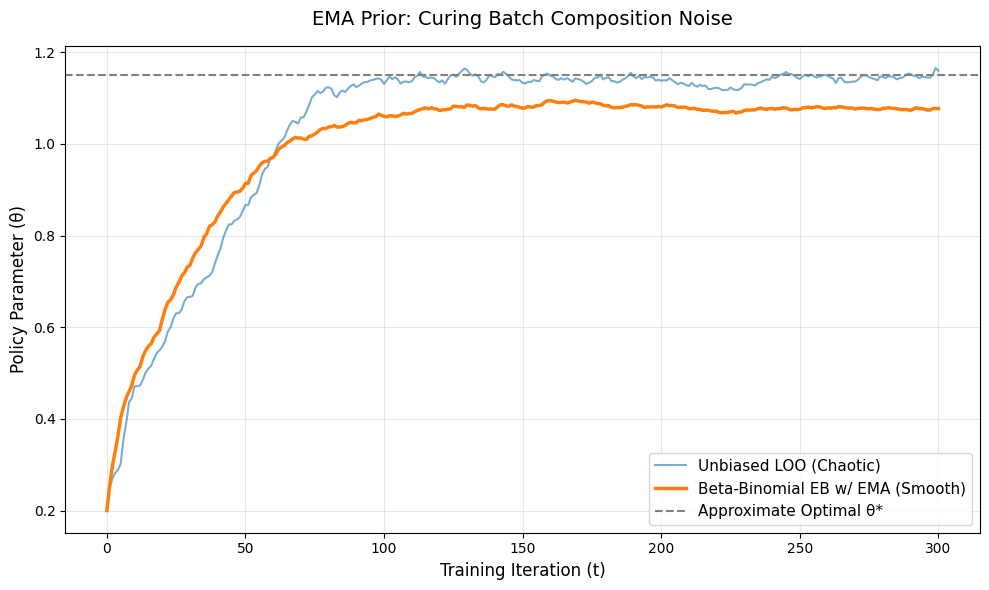

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from pass_at_k import BetaBinomialPassAtK

# =====================================================================
# 1. SETUP THE ENVIRONMENT
# =====================================================================
sigma = 0.1
n_problems = 64
n_generations = 10
iterations = 300
initial_theta = 0.2
base_lr = 1.0

# The EMA Momentum (0.0 = completely local, 1.0 = completely frozen)
# 0.9 means we keep 90% of our global history and mix in 10% of the new batch
ema_decay = 0.90 

eb_bb = BetaBinomialPassAtK(verbose=False)

thetas = {
    'Unbiased LOO': initial_theta, 
    'Beta-Binomial EB (EMA)': initial_theta
}

trajectories = {
    'Unbiased LOO': [initial_theta], 
    'Beta-Binomial EB (EMA)': [initial_theta]
}

# Initialize our Global Prior trackers
global_alpha = None
global_beta = None

print("Starting Stochastic Gradient Ascent with EMA Prior...")

# =====================================================================
# 2. THE TRAINING LOOP
# =====================================================================
for t in range(1, iterations + 1):
    lr = base_lr / np.sqrt(t)
    
    # Fresh, random mini-batch
    X = np.random.uniform(0.5, 1.5, n_problems)
    W = 0.07 - 0.04 * X
    
    for method in thetas.keys():
        current_theta = thetas[method]
        
        # 1. ROLLOUT
        Z = np.random.normal(loc=current_theta * X[:, None], scale=sigma, size=(n_problems, n_generations))
        P_succ = np.exp(-((Z - X[:, None]**2)**2) / W[:, None])
        Y = np.random.binomial(1, P_succ)
        
        # 2. SCORE
        score = ((Z - current_theta * X[:, None]) * X[:, None]) / sigma**2
        
        # 3. ADVANTAGE
        if method == 'Unbiased LOO':
            p_ub = np.max(Y, axis=1, keepdims=True)
            sum_others = np.sum(Y, axis=1, keepdims=True) - Y
            loo_baseline = (sum_others > 0).astype(float)
            adv = p_ub - loo_baseline
            
        elif method == 'Beta-Binomial EB (EMA)':
            if global_alpha is None:
                base_a, base_b = 1.0, 1.0
            else:
                base_a, base_b = global_alpha, global_beta
            eb_bb.alpha_, eb_bb.beta_ = base_a, base_b
            eb_bb.predict([n_generations - 1], method="integrated")
            psi_km1 = float(np.asarray(eb_bb._psi).ravel()[0])
            eb_bb.predict([n_generations], method="integrated")
            psi_k = float(np.asarray(eb_bb._psi).ravel()[0])
            p_bb = np.maximum(psi_km1, Y)
            adv = p_bb - psi_k
            eb_bb.fit(Y.sum(axis=1), [n_generations] * n_problems)
            if global_alpha is None:
                global_alpha = eb_bb.alpha_
                global_beta = eb_bb.beta_
            else:
                global_alpha = ema_decay * global_alpha + (1 - ema_decay) * eb_bb.alpha_
                global_beta = ema_decay * global_beta + (1 - ema_decay) * eb_bb.beta_

        # 4. ASCENT
        g = np.mean(adv * score)
        thetas[method] += lr * g
        trajectories[method].append(thetas[method])

# =====================================================================
# 3. PLOT
# =====================================================================
plt.figure(figsize=(10, 6))
plt.plot(trajectories['Unbiased LOO'], label='Unbiased LOO (Chaotic)', alpha=0.6, color='#1f77b4')
plt.plot(trajectories['Beta-Binomial EB (EMA)'], label='Beta-Binomial EB w/ EMA (Smooth)', linewidth=2.5, color='#ff7f0e')

plt.title("EMA Prior: Curing Batch Composition Noise", fontsize=14, pad=15)
plt.xlabel("Training Iteration (t)", fontsize=12)
plt.ylabel("Policy Parameter (θ)", fontsize=12)
plt.axhline(1.15, color='gray', linestyle='--', label='Approximate Optimal θ*')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Starting Stochastic Gradient Ascent with EMA Priors...
Final Thetas:
  Unbiased LOO: 1.1443
  Beta-Binomial EB: 1.0382
  NPMLE EB: 1.0594


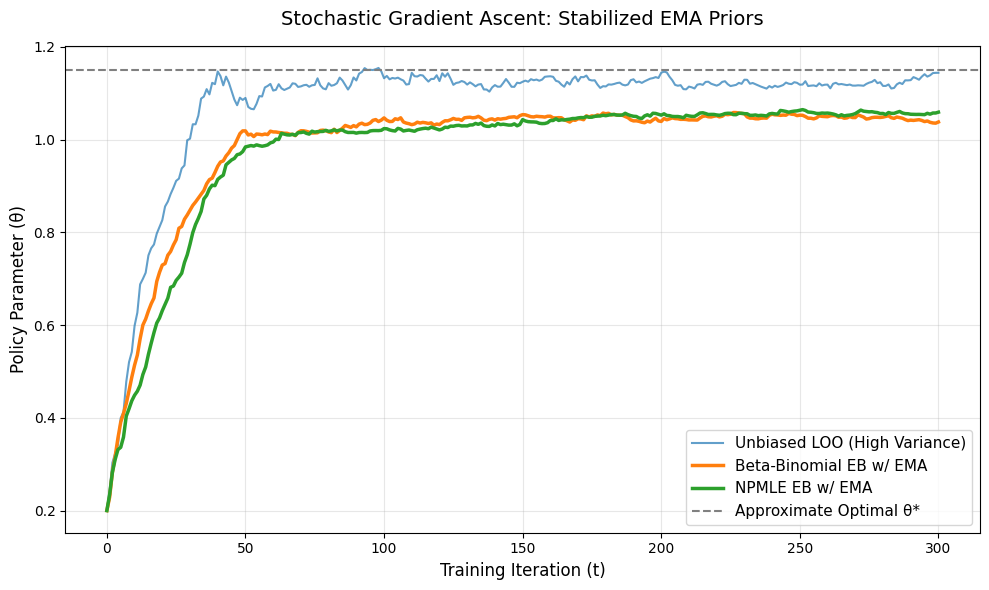

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pass_at_k import BetaBinomialPassAtK, NPMLEBinomialPassAtK

# =====================================================================
# 1. SETUP THE ENVIRONMENT
# =====================================================================
sigma = 0.1
n_problems = 64
n_generations = 8
iterations = 300
initial_theta = 0.2
base_lr = 1 # Base Learning Rate

# --- EMA Configuration ---
ema_decay = 0.80 

# Initialize the models
eb_bb = BetaBinomialPassAtK(verbose=False)
eb_npmle = NPMLEBinomialPassAtK(verbose=False, reg_alpha=1e-3, include_empirical_support=False)

# Track the parameter trajectories
thetas = {
    'Unbiased LOO': initial_theta, 
    'Beta-Binomial EB': initial_theta, 
    'NPMLE EB': initial_theta
}

trajectories = {
    'Unbiased LOO': [initial_theta], 
    'Beta-Binomial EB': [initial_theta], 
    'NPMLE EB': [initial_theta]
}

# --- Global Prior Trackers ---
global_alpha = None
global_beta = None
global_w = None  

print("Starting Stochastic Gradient Ascent with EMA Priors...")

# =====================================================================
# 2. THE TRAINING LOOP
# =====================================================================
for t in range(1, iterations + 1):
    # The Decaying Learning Rate (1/sqrt(t))
    lr = base_lr / np.sqrt(t)
    
    # Sample a fresh, random mini-batch of problems
    X = np.random.uniform(0.5, 1.5, n_problems)
    W = 0.07 - 0.04 * X
    
    # Train each estimator independently
    for method in thetas.keys():
        current_theta = thetas[method]
        
        # 1. ROLLOUT: Generate actions and environment rewards
        Z = np.random.normal(loc=current_theta * X[:, None], scale=sigma, size=(n_problems, n_generations))
        P_succ = np.exp(-((Z - X[:, None]**2)**2) / W[:, None])
        Y = np.random.binomial(1, P_succ)
        
        # 2. COMPUTE SCORE FUNCTION
        score = ((Z - current_theta * X[:, None]) * X[:, None]) / sigma**2
        
        # 3. COMPUTE ADVANTAGE & GRADIENT
        if method == 'Unbiased LOO':
            p_ub = np.max(Y, axis=1, keepdims=True)
            sum_others = np.sum(Y, axis=1, keepdims=True) - Y
            loo_baseline = (sum_others > 0).astype(float)
            adv = p_ub - loo_baseline
            
        elif method == 'Beta-Binomial EB':
            # Marginal pass@k under EMA hyperprior before this batch (uninformative on first step)
            if global_alpha is None:
                base_a, base_b = 1.0, 1.0
            else:
                base_a, base_b = global_alpha, global_beta
            eb_bb.alpha_, eb_bb.beta_ = base_a, base_b
            eb_bb.predict([n_generations - 1], method="integrated")
            psi_km1 = float(np.asarray(eb_bb._psi).ravel()[0])
            eb_bb.predict([n_generations], method="integrated")
            psi_k = float(np.asarray(eb_bb._psi).ravel()[0])
            p_bb = np.maximum(psi_km1, Y)
            adv = p_bb - psi_k
            eb_bb.fit(Y.sum(axis=1), [n_generations] * n_problems)
            if global_alpha is None:
                global_alpha = eb_bb.alpha_
                global_beta = eb_bb.beta_
            else:
                global_alpha = ema_decay * global_alpha + (1 - ema_decay) * eb_bb.alpha_
                global_beta = ema_decay * global_beta + (1 - ema_decay) * eb_bb.beta_
            
        elif method == 'NPMLE EB':
            eb_npmle.fit(Y.sum(axis=1), [n_generations]*n_problems)
            
            # --- EMA UPDATE ---
            if global_w is None or global_w.shape != eb_npmle.w_.shape:
                global_w = np.copy(eb_npmle.w_)
            else:
                global_w = ema_decay * global_w + (1 - ema_decay) * eb_npmle.w_
                
            # Override local prior with the stable global history
            eb_npmle.w_ = global_w
            
            eb_npmle.predict([n_generations-1], method="posterior")
            p_npmle = np.maximum(np.tile(eb_npmle._psi[:, [0]], (1, n_generations)), Y)
            
            eb_npmle.predict([n_generations], method="posterior")
            baseline_npmle = eb_npmle._psi[:, [0]] 
            adv = p_npmle - baseline_npmle

        # Compute the final expected gradient for the batch
        g = np.mean(adv * score)
        
        # 4. APPLY GRADIENT ASCENT
        thetas[method] += lr * g
        trajectories[method].append(thetas[method])

print(f"Final Thetas:")
for m, vals in trajectories.items():
    print(f"  {m}: {vals[-1]:.4f}")

# =====================================================================
# 3. PLOT THE LEARNING CURVES
# =====================================================================
plt.figure(figsize=(10, 6))
plt.plot(trajectories['Unbiased LOO'], label='Unbiased LOO (High Variance)', alpha=0.7, color='#1f77b4')
plt.plot(trajectories['Beta-Binomial EB'], label='Beta-Binomial EB w/ EMA', linewidth=2.5, color='#ff7f0e')
plt.plot(trajectories['NPMLE EB'], label='NPMLE EB w/ EMA', linewidth=2.5, color='#2ca02c')

plt.title("Stochastic Gradient Ascent: Stabilized EMA Priors", fontsize=14, pad=15)
plt.xlabel("Training Iteration (t)", fontsize=12)
plt.ylabel("Policy Parameter (θ)", fontsize=12)

# Assuming optimal theta for k=10 is around 1.15 based on our previous analytical curves
plt.axhline(1.15, color='gray', linestyle='--', label='Approximate Optimal θ*')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Starting Stochastic Gradient Ascent with Control Variates...
Final Thetas:
  Unbiased LOO: 1.1258
  Beta-Binomial EB: 1.0415
  NPMLE EB: 1.0376
  CV (c=1): 1.1349
  CV (Optimal c*): 1.1543


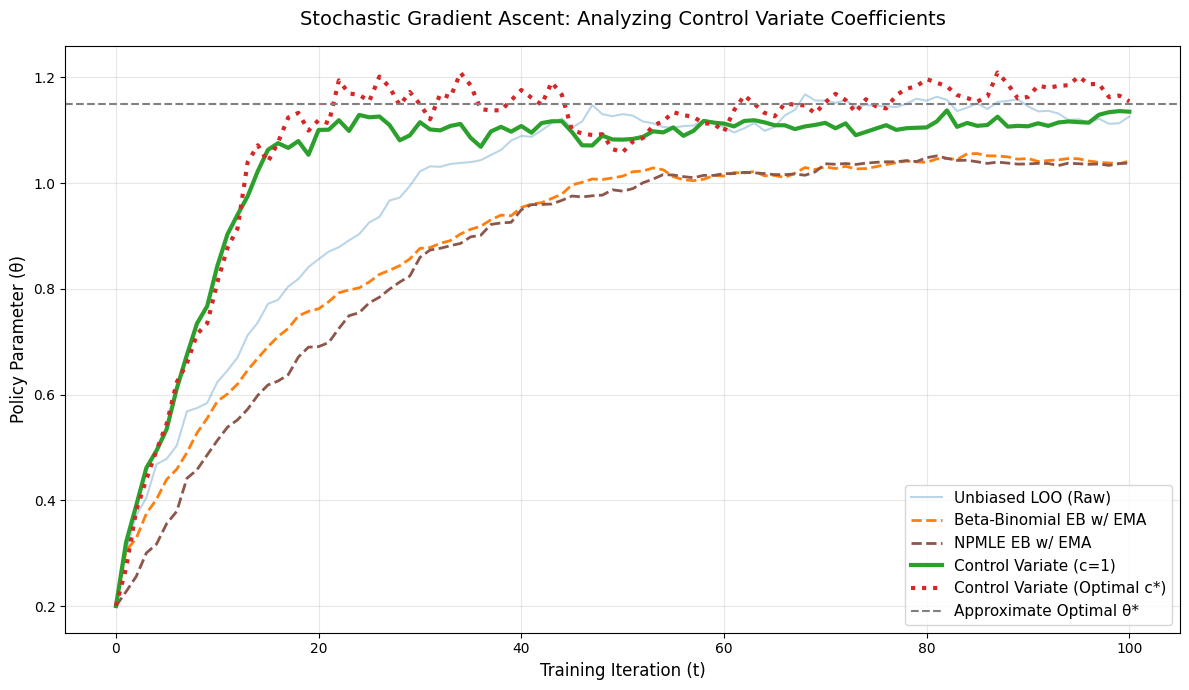

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pass_at_k import BetaBinomialPassAtK, NPMLEBinomialPassAtK

# =====================================================================
# 1. SETUP THE ENVIRONMENT
# =====================================================================
sigma = 0.1
n_problems = 64
n_generations = 8
iterations = 100
initial_theta = 0.2
base_lr = 1 # Base Learning Rate

# --- EMA Configuration ---
ema_decay = 0.80 

# Initialize the models
eb_bb = BetaBinomialPassAtK(verbose=False)
eb_npmle = NPMLEBinomialPassAtK(verbose=False, reg_alpha=1e-3, include_empirical_support=False)

# Track the parameter trajectories
thetas = {
    'Unbiased LOO': initial_theta, 
    'Beta-Binomial EB': initial_theta, 
    'NPMLE EB': initial_theta,
    'CV (c=1)': initial_theta,
    'CV (Optimal c*)': initial_theta
}

trajectories = {method: [initial_theta] for method in thetas.keys()}

# --- Global Prior Trackers ---
# Creating a dictionary to prevent the CV methods from cross-contaminating the pure EB methods
global_alpha = {k: None for k in thetas.keys() if 'EB' in k or 'CV' in k}
global_beta = {k: None for k in thetas.keys() if 'EB' in k or 'CV' in k}
global_w = None  

print("Starting Stochastic Gradient Ascent with Control Variates...")

# =====================================================================
# 2. THE TRAINING LOOP
# =====================================================================
for t in range(1, iterations + 1):
    lr = base_lr / np.sqrt(t)
    
    X = np.random.uniform(0.5, 1.5, n_problems)
    W = 0.07 - 0.04 * X
    
    for method in thetas.keys():
        current_theta = thetas[method]
        
        # 1. ROLLOUT: Generate actions and environment rewards
        Z = np.random.normal(loc=current_theta * X[:, None], scale=sigma, size=(n_problems, n_generations))
        P_succ = np.exp(-((Z - X[:, None]**2)**2) / W[:, None])
        Y = np.random.binomial(1, P_succ)
        
        # 2. COMPUTE SCORE FUNCTION
        score = ((Z - current_theta * X[:, None]) * X[:, None]) / sigma**2
        
        # 3. COMPUTE ADVANTAGE & GRADIENT
        if method == 'Unbiased LOO':
            p_ub = np.max(Y, axis=1, keepdims=True)
            sum_others = np.sum(Y, axis=1, keepdims=True) - Y
            loo_baseline = (sum_others > 0).astype(float)
            adv = p_ub - loo_baseline
            g = np.mean(adv * score)
            
        elif method == 'Beta-Binomial EB':
            if global_alpha[method] is None:
                base_a, base_b = 1.0, 1.0
            else:
                base_a, base_b = global_alpha[method], global_beta[method]
            eb_bb.alpha_, eb_bb.beta_ = base_a, base_b
            eb_bb.predict([n_generations - 1], method="integrated")
            psi_km1 = float(np.asarray(eb_bb._psi).ravel()[0])
            eb_bb.predict([n_generations], method="integrated")
            psi_k = float(np.asarray(eb_bb._psi).ravel()[0])
            p_bb = np.maximum(psi_km1, Y)
            adv = p_bb - psi_k
            g = np.mean(adv * score)
            eb_bb.fit(Y.sum(axis=1), [n_generations] * n_problems)
            if global_alpha[method] is None:
                global_alpha[method], global_beta[method] = eb_bb.alpha_, eb_bb.beta_
            else:
                global_alpha[method] = ema_decay * global_alpha[method] + (1 - ema_decay) * eb_bb.alpha_
                global_beta[method] = ema_decay * global_beta[method] + (1 - ema_decay) * eb_bb.beta_
            
        elif method == 'NPMLE EB':
            eb_npmle.fit(Y.sum(axis=1), [n_generations]*n_problems)
            # EMA on w_; reset if grid length changed (e.g. if include_empirical_support True)
            if global_w is None or global_w.shape != eb_npmle.w_.shape:
                global_w = np.copy(eb_npmle.w_)
            else:
                global_w = ema_decay * global_w + (1 - ema_decay) * eb_npmle.w_
                
            eb_npmle.w_ = global_w
            eb_npmle.predict([n_generations-1], method="posterior")
            p_npmle = np.maximum(np.tile(eb_npmle._psi[:, [0]], (1, n_generations)), Y)
            eb_npmle.predict([n_generations], method="posterior")
            adv = p_npmle - eb_npmle._psi[:, [0]] 
            g = np.mean(adv * score)
            
        elif 'CV' in method:
            # A. Compute Unbiased LOO Advantage (X)
            p_ub = np.max(Y, axis=1, keepdims=True)
            sum_others = np.sum(Y, axis=1, keepdims=True) - Y
            loo_baseline = (sum_others > 0).astype(float)
            adv_loo = p_ub - loo_baseline
            
            # B. Beta-Binomial EB advantage — marginal under EMA hyperprior before this batch
            if global_alpha[method] is None:
                base_a, base_b = 1.0, 1.0
            else:
                base_a, base_b = global_alpha[method], global_beta[method]
            eb_bb.alpha_, eb_bb.beta_ = base_a, base_b
            eb_bb.predict([n_generations - 1], method="integrated")
            psi_km1 = float(np.asarray(eb_bb._psi).ravel()[0])
            eb_bb.predict([n_generations], method="integrated")
            psi_k = float(np.asarray(eb_bb._psi).ravel()[0])
            P_k_minus_1 = np.full((n_problems, 1), psi_km1)
            p_bb = np.maximum(psi_km1, Y)
            adv_eb = p_bb - psi_k
            eb_bb.fit(Y.sum(axis=1), [n_generations] * n_problems)
            if global_alpha[method] is None:
                global_alpha[method], global_beta[method] = eb_bb.alpha_, eb_bb.beta_
            else:
                global_alpha[method] = ema_decay * global_alpha[method] + (1 - ema_decay) * eb_bb.alpha_
                global_beta[method] = ema_decay * global_beta[method] + (1 - ema_decay) * eb_bb.beta_
            
            # C. Compute Analytical Expected Surrogate Gradient E[Y]
            D = W + 2 * sigma**2
            true_p_X = np.sqrt(W / D) * np.exp(-((current_theta * X - X**2)**2) / D)
            grad_p_X = true_p_X * (-2 * (current_theta * X - X**2) * X / D)
            A_gap = 1.0 - P_k_minus_1.ravel()
            expected_g_eb = np.mean(A_gap * grad_p_X)
            
            # D. Compute individual gradients to calculate Covariance
            g_loo_i = adv_loo * score
            g_eb_i = adv_eb * score
            
            # E. The Control Variate Logic
            if method == 'CV (c=1)':
                c = 1.0
            elif method == 'CV (Optimal c*)':
                # Calculate empirical covariance matrix for the batch
                cov = np.cov(g_loo_i.ravel(), g_eb_i.ravel())[0, 1]
                var_y = np.var(g_eb_i.ravel()) + 1e-8
                c = cov / var_y
                
            # Final Doubly Robust Gradient
            g = expected_g_eb + c * np.mean(g_loo_i - g_eb_i)

        # 4. APPLY GRADIENT ASCENT
        thetas[method] += lr * g
        trajectories[method].append(thetas[method])

print(f"Final Thetas:")
for m, vals in trajectories.items():
    print(f"  {m}: {vals[-1]:.4f}")

# =====================================================================
# 3. PLOT THE LEARNING CURVES
# =====================================================================
plt.figure(figsize=(12, 7))

plt.plot(trajectories['Unbiased LOO'], label='Unbiased LOO (Raw)', alpha=0.3, color='#1f77b4')
plt.plot(trajectories['Beta-Binomial EB'], label='Beta-Binomial EB w/ EMA', linewidth=2, color='#ff7f0e', linestyle='--')
plt.plot(trajectories['NPMLE EB'], label='NPMLE EB w/ EMA', linewidth=2, color='#8c564b', linestyle='--')

plt.plot(trajectories['CV (c=1)'], label='Control Variate (c=1)', linewidth=3, color='#2ca02c')
plt.plot(trajectories['CV (Optimal c*)'], label='Control Variate (Optimal c*)', linewidth=3, color='#d62728', linestyle=':')

plt.title("Stochastic Gradient Ascent: Analyzing Control Variate Coefficients", fontsize=14, pad=15)
plt.xlabel("Training Iteration (t)", fontsize=12)
plt.ylabel("Policy Parameter (θ)", fontsize=12)
plt.axhline(1.15, color='gray', linestyle='--', label='Approximate Optimal θ*')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Starting Stochastic Gradient Ascent with Annealed Hybrid Advantage...
Final Thetas:
  Unbiased LOO: 1.1224
  Beta-Binomial EB: 0.9452
  NPMLE EB: 1.0396
  CV (c=1): 1.1181
  CV (Optimal c*): 1.0113
  Annealed Hybrid (GAE-style): 1.1075


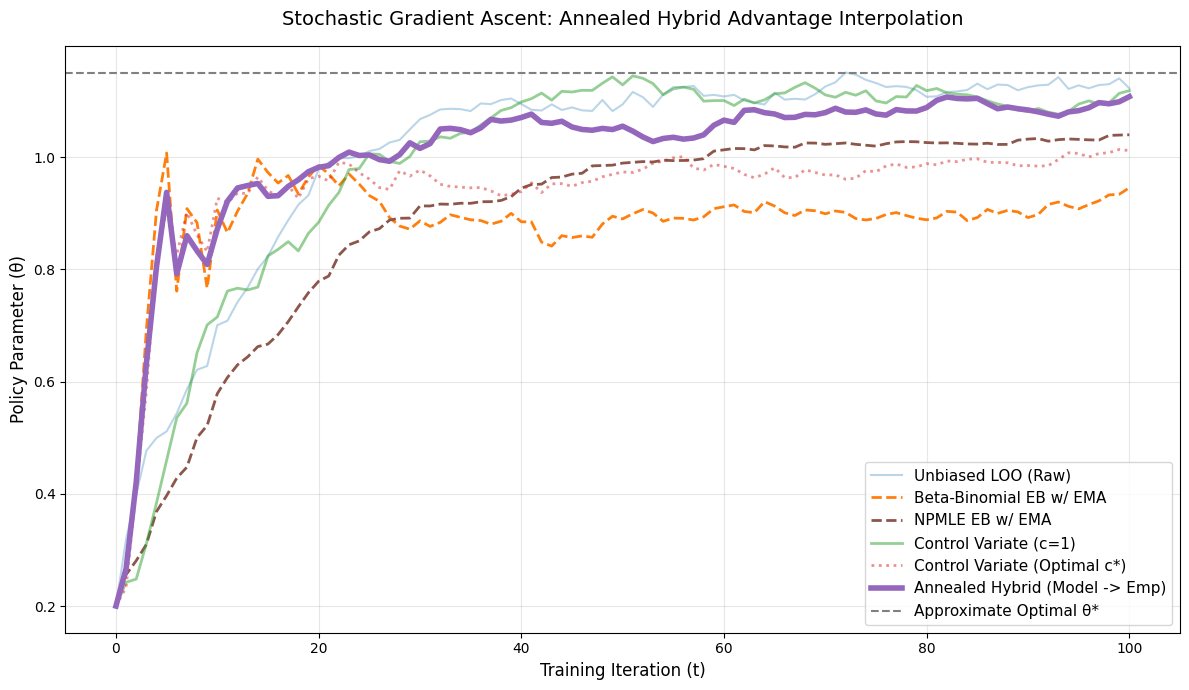

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pass_at_k import BetaBinomialPassAtK, NPMLEBinomialPassAtK

# =====================================================================
# 1. SETUP THE ENVIRONMENT
# =====================================================================
sigma = 0.1
n_problems = 64
n_generations = 8
iterations = 100
initial_theta = 0.2
base_lr = 1.0 # Base Learning Rate

# --- EMA Configuration ---
ema_decay = 0.90 

# Initialize the models
eb_bb = BetaBinomialPassAtK(verbose=False)
eb_npmle = NPMLEBinomialPassAtK(verbose=False, reg_alpha=1e-3, include_empirical_support=False)

# Track the parameter trajectories
thetas = {
    'Unbiased LOO': initial_theta, 
    'Beta-Binomial EB': initial_theta, 
    'NPMLE EB': initial_theta,
    'CV (c=1)': initial_theta,
    'CV (Optimal c*)': initial_theta,
    'Annealed Hybrid (GAE-style)': initial_theta
}

trajectories = {method: [initial_theta] for method in thetas.keys()}

# --- Global Prior Trackers ---
global_alpha = {k: None for k in thetas.keys() if 'EB' in k or 'CV' in k or 'Hybrid' in k}
global_beta = {k: None for k in thetas.keys() if 'EB' in k or 'CV' in k or 'Hybrid' in k}
global_w = None  

print("Starting Stochastic Gradient Ascent with Annealed Hybrid Advantage...")

# =====================================================================
# 2. THE TRAINING LOOP
# =====================================================================
for t in range(1, iterations + 1):
    lr = base_lr / np.sqrt(t)
    
    X = np.random.uniform(0.5, 1.5, n_problems)
    W = 0.07 - 0.04 * X
    
    for method in thetas.keys():
        current_theta = thetas[method]
        
        # 1. ROLLOUT: Generate actions and environment rewards
        Z = np.random.normal(loc=current_theta * X[:, None], scale=sigma, size=(n_problems, n_generations))
        P_succ = np.exp(-((Z - X[:, None]**2)**2) / W[:, None])
        Y = np.random.binomial(1, P_succ)
        
        # 2. COMPUTE SCORE FUNCTION
        score = ((Z - current_theta * X[:, None]) * X[:, None]) / sigma**2
        
        # 3. COMPUTE ADVANTAGE & GRADIENT
        if method == 'Unbiased LOO':
            p_ub = np.max(Y, axis=1, keepdims=True)
            sum_others = np.sum(Y, axis=1, keepdims=True) - Y
            loo_baseline = (sum_others > 0).astype(float)
            adv = p_ub - loo_baseline
            g = np.mean(adv * score)
            
        elif method == 'Beta-Binomial EB':
            if global_alpha[method] is None:
                base_a, base_b = 1.0, 1.0
            else:
                base_a, base_b = global_alpha[method], global_beta[method]
            eb_bb.alpha_, eb_bb.beta_ = base_a, base_b
            eb_bb.predict([n_generations - 1], method="integrated")
            psi_km1 = float(np.asarray(eb_bb._psi).ravel()[0])
            eb_bb.predict([n_generations], method="integrated")
            psi_k = float(np.asarray(eb_bb._psi).ravel()[0])
            p_bb = np.maximum(psi_km1, Y)
            adv = p_bb - psi_k
            g = np.mean(adv * score)
            eb_bb.fit(Y.sum(axis=1), [n_generations] * n_problems)
            if global_alpha[method] is None:
                global_alpha[method], global_beta[method] = eb_bb.alpha_, eb_bb.beta_
            else:
                global_alpha[method] = ema_decay * global_alpha[method] + (1 - ema_decay) * eb_bb.alpha_
                global_beta[method] = ema_decay * global_beta[method] + (1 - ema_decay) * eb_bb.beta_

        elif method == 'NPMLE EB':
            eb_npmle.fit(Y.sum(axis=1), [n_generations]*n_problems)
            if global_w is None or global_w.shape != eb_npmle.w_.shape:
                global_w = np.copy(eb_npmle.w_)
            else:
                global_w = ema_decay * global_w + (1 - ema_decay) * eb_npmle.w_
                
            eb_npmle.w_ = global_w
            eb_npmle.predict([n_generations-1], method="posterior")
            p_npmle = np.maximum(np.tile(eb_npmle._psi[:, [0]], (1, n_generations)), Y)
            eb_npmle.predict([n_generations], method="posterior")
            adv = p_npmle - eb_npmle._psi[:, [0]] 
            g = np.mean(adv * score)
            
        elif 'CV' in method:
            p_ub = np.max(Y, axis=1, keepdims=True)
            sum_others = np.sum(Y, axis=1, keepdims=True) - Y
            loo_baseline = (sum_others > 0).astype(float)
            adv_loo = p_ub - loo_baseline
            
            if global_alpha[method] is None:
                base_a, base_b = 1.0, 1.0
            else:
                base_a, base_b = global_alpha[method], global_beta[method]
            eb_bb.alpha_, eb_bb.beta_ = base_a, base_b
            eb_bb.predict([n_generations - 1], method="integrated")
            psi_km1 = float(np.asarray(eb_bb._psi).ravel()[0])
            eb_bb.predict([n_generations], method="integrated")
            psi_k = float(np.asarray(eb_bb._psi).ravel()[0])
            P_k_minus_1 = np.full((n_problems, 1), psi_km1)
            p_bb = np.maximum(psi_km1, Y)
            adv_eb = p_bb - psi_k
            eb_bb.fit(Y.sum(axis=1), [n_generations] * n_problems)
            if global_alpha[method] is None:
                global_alpha[method], global_beta[method] = eb_bb.alpha_, eb_bb.beta_
            else:
                global_alpha[method] = ema_decay * global_alpha[method] + (1 - ema_decay) * eb_bb.alpha_
                global_beta[method] = ema_decay * global_beta[method] + (1 - ema_decay) * eb_bb.beta_
            
            D = W + 2 * sigma**2
            true_p_X = np.sqrt(W / D) * np.exp(-((current_theta * X - X**2)**2) / D)
            grad_p_X = true_p_X * (-2 * (current_theta * X - X**2) * X / D)
            A_gap = 1.0 - P_k_minus_1.ravel()
            expected_g_eb = np.mean(A_gap * grad_p_X)
            
            g_loo_i = adv_loo * score
            g_eb_i = adv_eb * score
            
            if method == 'CV (c=1)':
                c = 1.0
            elif method == 'CV (Optimal c*)':
                cov = np.cov(g_loo_i.ravel(), g_eb_i.ravel())[0, 1]
                var_y = np.var(g_eb_i.ravel()) + 1e-8
                c = cov / var_y
                
            g = expected_g_eb + c * np.mean(g_loo_i - g_eb_i)

        elif method == 'Annealed Hybrid (GAE-style)':
            # A. Compute Unbiased Empirical Advantage (A_emp)
            p_ub = np.max(Y, axis=1, keepdims=True)
            sum_others = np.sum(Y, axis=1, keepdims=True) - Y
            loo_baseline = (sum_others > 0).astype(float)
            adv_emp = p_ub - loo_baseline

            # B. Model advantage — marginal under EMA hyperprior before this batch
            if global_alpha[method] is None:
                base_a, base_b = 1.0, 1.0
            else:
                base_a, base_b = global_alpha[method], global_beta[method]
            eb_bb.alpha_, eb_bb.beta_ = base_a, base_b
            eb_bb.predict([n_generations - 1], method="integrated")
            psi_km1 = float(np.asarray(eb_bb._psi).ravel()[0])
            eb_bb.predict([n_generations], method="integrated")
            psi_k = float(np.asarray(eb_bb._psi).ravel()[0])
            p_bb = np.maximum(psi_km1, Y)
            adv_model = p_bb - psi_k
            eb_bb.fit(Y.sum(axis=1), [n_generations] * n_problems)
            if global_alpha[method] is None:
                global_alpha[method], global_beta[method] = eb_bb.alpha_, eb_bb.beta_
            else:
                global_alpha[method] = ema_decay * global_alpha[method] + (1 - ema_decay) * eb_bb.alpha_
                global_beta[method] = ema_decay * global_beta[method] + (1 - ema_decay) * eb_bb.beta_

            # C. Anneal Lambda from 0 -> 1 over the total iterations
            # At t=1, lambda_t = 0.0 (Pure Model)
            # At t=iterations, lambda_t = 1.0 (Pure Empirical)
            # lambda_t = (t - 1) / (iterations - 1) if iterations > 1 else 1.0
            # lambda_t = lambda_t ** (1/4)
            if t < 10:
                lambda_t = 0.0
            else:
                lambda_t = 1.0
            # D. The Interpolated Hybrid Advantage
            adv_hybrid = lambda_t * adv_emp + (1 - lambda_t) * adv_model
            # adv_hybrid = adv_emp
            g = np.mean(adv_hybrid * score)

        # 4. APPLY GRADIENT ASCENT
        thetas[method] += lr * g
        trajectories[method].append(thetas[method])

print(f"Final Thetas:")
for m, vals in trajectories.items():
    print(f"  {m}: {vals[-1]:.4f}")

# =====================================================================
# 3. PLOT THE LEARNING CURVES
# =====================================================================
plt.figure(figsize=(12, 7))

plt.plot(trajectories['Unbiased LOO'], label='Unbiased LOO (Raw)', alpha=0.3, color='#1f77b4')
plt.plot(trajectories['Beta-Binomial EB'], label='Beta-Binomial EB w/ EMA', linewidth=2, color='#ff7f0e', linestyle='--')
plt.plot(trajectories['NPMLE EB'], label='NPMLE EB w/ EMA', linewidth=2, color='#8c564b', linestyle='--')

plt.plot(trajectories['CV (c=1)'], label='Control Variate (c=1)', linewidth=2, color='#2ca02c', alpha=0.5)
plt.plot(trajectories['CV (Optimal c*)'], label='Control Variate (Optimal c*)', linewidth=2, color='#d62728', linestyle=':', alpha=0.5)

# Emphasize the new Annealed Hybrid method
plt.plot(trajectories['Annealed Hybrid (GAE-style)'], label='Annealed Hybrid (Model -> Emp)', linewidth=4, color='#9467bd')

plt.title("Stochastic Gradient Ascent: Annealed Hybrid Advantage Interpolation", fontsize=14, pad=15)
plt.xlabel("Training Iteration (t)", fontsize=12)
plt.ylabel("Policy Parameter (θ)", fontsize=12)
plt.axhline(1.15, color='gray', linestyle='--', label='Approximate Optimal θ*')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()